In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
import matplotlib.pyplot as plt
import transformer as mlt
import supervisedFT as sft

In [2]:
m = mlt.LLM(Rope = True).to(mlt.device)
for p in m.parameters():
    p.requires_grad = True

for block in m.blocks:
    block.heads.qkvs.A.requires_grad = False
    block.heads.qkvs.B.requires_grad = False
    block.heads.WO.A.requires_grad = False
    block.heads.WO.B.requires_grad = False
optimizer = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=mlt.lr,weight_decay=0.01)


The training loss at step 0 is 7.306041240692139
The validation loss at step 0 is 5.410552978515625
The training loss at step 100 is 2.690717558860779
The validation loss at step 100 is 2.335948085784912
The training loss at step 200 is 2.1991069293022156
The validation loss at step 200 is 2.102574014663696
The training loss at step 300 is 2.0140354800224305
The validation loss at step 300 is 1.9462953090667725
The training loss at step 400 is 1.8960632622241973
The validation loss at step 400 is 1.8459217548370361
The training loss at step 500 is 1.799588840007782
The validation loss at step 500 is 1.7572484254837035
The training loss at step 600 is 1.7263808536529541
The validation loss at step 600 is 1.7105915069580078
The training loss at step 700 is 1.6769829523563384
The validation loss at step 700 is 1.6535070896148683
The training loss at step 800 is 1.6266680908203126
The validation loss at step 800 is 1.6112090349197388
The training loss at step 900 is 1.58485147356987
The va

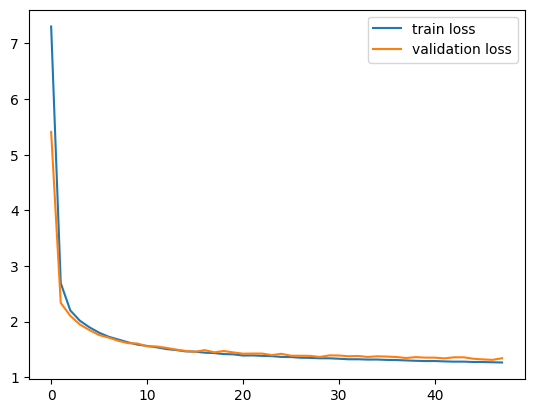

In [ ]:
####Pretraining loop

train_loss = []
val_loss = []
train_plot = []
val_plot = []
m.train()
n=0
for _ in range(mlt.steps):
    X, Y = mlt.get_batch('train')
    logit, loss = m(X, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item())
    if _%100 in [96,97,98,99,0]:
        Xval, Yval = mlt.get_batch('val')
        logit, valloss = m(Xval, Yval)
        val_loss.append(valloss.item())
        if _%100 == 0:
            train_loss_avg = sum(train_loss)/len(train_loss)
            val_loss_avg = sum(val_loss)/len(val_loss)
            train_plot.append(train_loss_avg)
            val_plot.append(val_loss_avg)
            print(f"The training loss at step {_} is {train_loss_avg}")
            print(f"The validation loss at step {_} is {val_loss_avg}")
            train_loss = []
            val_loss = []
            if val_loss_avg> train_loss_avg:
                n += 1
    if n>3:
        break
plt.plot(train_plot, label = 'train loss')
plt.plot(val_plot, label = 'validation loss')
plt.legend()
plt.show()

In [4]:
for p in m.parameters():
    p.requires_grad = False

for block in m.blocks:
    block.heads.qkvs.A.requires_grad = True
    block.heads.qkvs.B.requires_grad = True
    block.heads.WO.A.requires_grad = True
    block.heads.WO.B.requires_grad = True

optimizer = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=sft.lr,weight_decay=0.01)

The SFT training loss at step 0 is 2.980646848678589
The SFT validation loss at step 0 is 3.348982334136963
The SFT training loss at step 100 is 2.8824708676338195
The SFT validation loss at step 100 is 2.698790264129639
The SFT training loss at step 200 is 2.37442707657814
The SFT validation loss at step 200 is 2.3274988651275637
The SFT training loss at step 300 is 2.1130730533599853
The SFT validation loss at step 300 is 1.9935136318206788
The SFT training loss at step 400 is 1.9782201325893403
The SFT validation loss at step 400 is 2.033124303817749
The SFT training loss at step 500 is 1.9069457018375398
The SFT validation loss at step 500 is 1.9165497779846192
The SFT training loss at step 600 is 1.8491774106025696
The SFT validation loss at step 600 is 1.8775338649749755


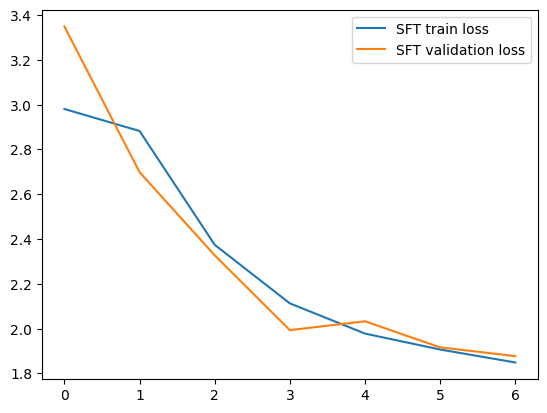

In [5]:
#### SFT loop

train_loss = []
val_loss = []
train_plot = []
val_plot = []
m.train()
n=0
for _ in range(sft.steps):
    X, Y = sft.get_batch('train')
    logit, loss = m(X, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item())
    if _%100 in [96,97,98,99,0]:
        Xval, Yval = sft.get_batch('val')
        logit, valloss = m(Xval, Yval)
        val_loss.append(valloss.item())
        if _%100 == 0:
            train_loss_avg = sum(train_loss)/len(train_loss)
            val_loss_avg = sum(val_loss)/len(val_loss)
            train_plot.append(train_loss_avg)
            val_plot.append(val_loss_avg)
            print(f"The SFT training loss at step {_} is {train_loss_avg}")
            print(f"The SFT validation loss at step {_} is {val_loss_avg}")
            train_loss = []
            val_loss = []
            if val_loss_avg> train_loss_avg:
                n += 1
    if n>3:
        break
plt.plot(train_plot, label = 'SFT train loss')
plt.plot(val_plot, label = 'SFT validation loss')
plt.legend()
plt.show()

In [6]:
inn = torch.tensor(mlt.bpe.encode('<bos> What is the capital of Iran?'), device=mlt.device)

In [7]:
inn = inn.reshape(1,-1)

In [8]:
m.eval()
out = m.generate_n(inn, 1000)

In [9]:
print(mlt.bpe.decode(out.tolist()[0]))

<bos> What is the capital of Iran? with shapebe
Banerman halter from Europeane, Mibil, Doubt is reviewe.<eos><eos>ė: Allah managed with Batal- Tomp Rhode , and began his forces.<eos><eos><eos>, finaмsɬ<eos>, which the area is Gerdeo, 190: No cap Level7
Cline is came, xag: Galfthoure is alive.<eos><eos>, shellx is city time morn water, Sahn in Dam when feeding probat.<eos>, steomatu stated,
CCl, 49–体: 
Ta“aa<eos><eos>-<eos><eos><eos>扈<eos><eos><eos><eos><eos>
Ric is Speed
Hed, or Iaz 's Jick<eos><eos><eos><eos>> CEC spant, and Weike bridge<eos>, Aln is Piratent velumetoox, Clogn review-Quine: American
Faiḷl Warn: Up op genantAdo Askely is Labbo
Stern
Marlac, Chisdologist: electroma: Holon, America Fourne<eos>: Rotteat Los Choleş: Amy.<eos>, Turphol.<eos><eos>, Barbourud, Besinc:: Stophroggetabag現κ<eos>و
Creas: Grid, Thicklyd<eos>
Sport, Plan Bacquiri, Japanese many string, Fowler GA and Bourbourg busies and 48 CFamble<eos><eos><eos><eos>ɳ<eos><eos>q<eos><eos>ạ selections of NorthwelMaxa